# PROYECTO: SEGMENTACIÓN DE CLIENTES CON GMM

En esta lección aplicaremos de forma práctica lo aprendido acerca de los Modelos de Mezcla Gaussiana (*Gaussian Mixture Models*, GMM) para resolver un problema de segmentación de clientes.

En particular, usaremos un set de datos que contiene información de diferentes clientes de un centro comercial y sus patrones de consumo asociados y entrenaremos un GMM para de forma no supervisada clasificar a cada cliente dentro del segmento más adecuado.

Contenido:
1. [El problema a resolver](#1.-El-problema-a-resolver)
2. [El set de datos](#2.-El-set-de-datos)
3. [Análisis exploratorio](#3.-Análisis-exploratorio)
4. [Pre-procesamiento de los datos](#4.-Pre-procesamiento-de-los-datos)
5. [Primer Modelo de Mezcla Gaussiana](#5.-Primer-Modelo-de-Mezcla-Gaussiana)
6. [¿Cómo seleccionar el número de *clusters*](#6.-¿Cómo-seleccionar-el-número-de-clusters?)
7. [Segmentación de los clientes](#7.-Segmentación-de-los-clientes)

## 1. El problema a resolver

> Usar un GMM para determinar el número más adecuado de segmentos y para caracterizar cada segmento de cliente

## 2. El set de datos

Para un total de 200 personas hemos recolectado la siguiente información:

- Género
- Edad
- Ingresos anuales (en miles de dólares)
- Puntaje: un valor entre 1 y 100 qué indica el nivel de compra del cliente

Realicemos la lectura de este set de datos:

In [1]:
import pandas as pd

# Leer dataset
RUTA = './'

df = pd.read_csv(RUTA + 'dataset_compradores.csv', index_col='ID')
df

,Género,Edad,Ingresos anuales (x1000USD),Puntaje (1-100)
ID,,,,
1,Masculino,19,15,39
2,Masculino,21,15,81
3,Femenino,20,16,6
4,Femenino,23,16,77
5,Femenino,31,17,40
...,...,...,...,...
196,Femenino,35,120,79
197,Femenino,45,126,28
198,Masculino,32,126,74


## 3. Análisis exploratorio

Como siempre, la primera fase es explorar nuestros datos. En primer lugar vemos que tenemos N = 200 registros y la dimensionalidad de nuestro dataset es igual a 4 (tenemos 4 *features*/variables/columnas).

En primer lugar podemos evidenciar que la columna *Género* no podrá ser usada al momento de construir el modelo. Esto principalmente por dos razones:

1. Porque es una variable categórica
2. Porque, incluso si la representamos numéricamente, **no es una variable continua** y los GMM hacen uso de distribuciones Gaussianas que se aplican únicamente a variables numéricas continuas.

> Observación: durante el pre-precesamiento eliminaremos la columna *Género*

Nos enfocaremos únicamente en las columnas restantes. Verifiquemos si contienen datos faltantes:

In [2]:
df.isna().sum()

Género                         0
Edad                           0
Ingresos anuales (x1000USD)    0
Puntaje (1-100)                0
dtype: int64

Perfecto, no hay datos faltantes!

Sin considerar la columna género, tendremos un set de datos con una dimensionalidad igual a 3 (variables Edad, ingresos anuales y puntaje).

Aunque podríamos intentar generar una gráfica 3D para explorar los datos, en la práctica muchas veces la dimensionalidad es mayor, lo cual nos impide visualizar fácilmente la distribución de los datos. Así que usaremos otras herramientas alternativas.

Una herramienta de exploración es calcular la matriz de correlación entre pares de variables numéricas. Esto nos permitirá ver si existe algún grado de relación entre las diferentes variables, o si por el contrario todas son independientes:

In [3]:
df.corr(numeric_only=True)

,Edad,Ingresos anuales (x1000USD),Puntaje (1-100)
Edad,1.000000,-0.012398,-0.327227
Ingresos anuales (x1000USD),-0.012398,1.000000,0.009903
Puntaje (1-100),-0.327227,0.009903,1.000000


Vemos que los índices de correlación son relativamente bajos (cercanos a 0) y por tanto podemos afirmar que las variables edad, ingresos y puntaje son independientes. Así que presentaremos estas tres variables al GMM.

También podemos analizar de forma gráfica pares de variables usando gráficos de dispersión. Esto podría ser útil para determinar cuáles podrían ser las variables más relevantes al momento de hacer la segmentación de clientes:

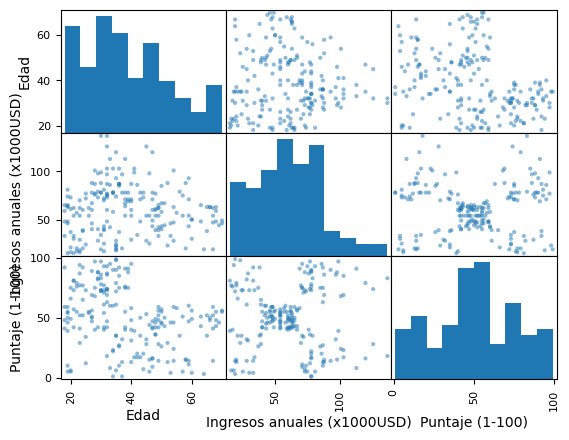

In [4]:
pd.plotting.scatter_matrix(df);

No resulta sencillo entender la gráfica anterior pues los nombres de cada variable son muy extensos. Modifiquemos estos nombres y generemos la gráfica nuevamente:

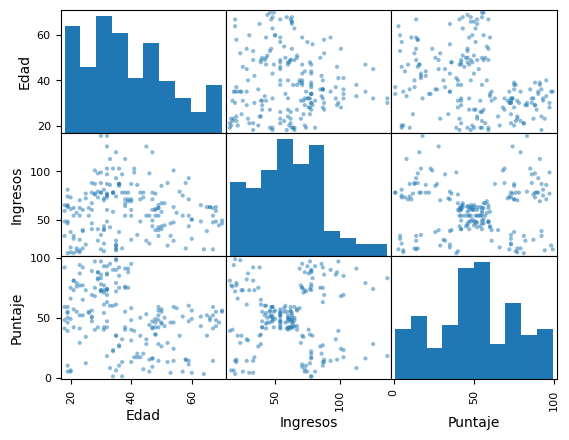

In [5]:
# Renombrar columnas Ingresos anuales (x1000USD) y Puntaje (1-100)
df = df.rename(columns={'Ingresos anuales (x1000USD)': 'Ingresos', 'Puntaje (1-100)':'Puntaje'})

# Generar gráfica
pd.plotting.scatter_matrix(df);

Vemos que por ejemplo la combinación de Edad-Puntaje o Edad-Ingresos no nos muestra agrupaciones claramente diferenciadas.

Por otra parte, la combinación Puntaje-Ingresos parece mostrar entre 4 y 5 agrupaciones de clientes. Estas dos variables podrían ser las más relevantes, aunque en todo caso presentaremos la totalidad de la información al GMM y de igual forma determinaremos el número adecuado de agrupaciones con el análisis que realizaremos más adelante.

## 4. Pre-procesamiento de los datos

En el análisis exploratorio mencionamos que era necesario eliminar la columna *Género*. Este será el primer paso del pre-procesamiento:

In [6]:
df = df.drop(columns=['Género'])
df

,Edad,Ingresos,Puntaje
ID,,,
1,19,15,39
2,21,15,81
3,20,16,6
4,23,16,77
5,31,17,40
...,...,...,...
196,35,120,79
197,45,126,28
198,32,126,74


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Edad      200 non-null    int64
 1   Ingresos  200 non-null    int64
 2   Puntaje   200 non-null    int64
dtypes: int64(3)
memory usage: 6.2 KB


El único paso restante del pre-procesamiento es extraer los datos numéricos del *DataFrame*. Además, debemos convertir el arreglo resultante al formato de punto flotante (*float*) pues el GMM hace cálculos que siempre generarán datos con cantidades decimales:

In [8]:
# Extraer arreglo de datos y convertirlo a formato punto flotante
X = df.to_numpy().astype('float')
print(X.shape)
print(X.dtype)

(200, 3)
float64


¡Perfecto! En este punto ya tenemos nuestro set de datos (de N=200 observaciones y D=3 dimensiones) en el formato *float64*.

Ya está todo listo para construir el Modelo de Mezcla Gaussiana.

## 5. Primer Modelo de Mezcla Gaussiana

Además del set de datos (X) el otro requisito antes de implementar el GMM es definir el número de agrupaciones (K).

Una manera de definir este número sería haciendo una gráfica de los datos y determinando, de forma visual, el número ideal de agrupaciones. Pero esto no siempre es posible, así que en la próxima sección veremos una forma rigurosa de establecer el número de agrupaciones.

Sin embargo, con el propósito de entender cómo entrenar un GMM supondremos que por ejemplo el número de agrupaciones es igual a 2.

El entrenamiento del GMM es muy sencillo y se puede realizar en muy pocas líneas de código usando el módulo *GaussianMixture* de la librería Scikit-Learn.

Comencemos importando el módulo, definiendo K y generando una instancia del modelo:

In [9]:
# Importar el módulo
from sklearn.mixture import GaussianMixture

# Definir el valor de K y crear una instancia
K = 2
gmm = GaussianMixture(n_components = K, random_state=42)

En este punto hemos creado una instancia del modelo (variable *gmm*) y la hemos inicializado.

Recordemos que en la inicialización lo que se hace es asignar valores iniciales a $\pi_k$, $\mu_k$ y $\Sigma_k$ y existen diferentes maneras de hacerlo.

En este caso, por defecto *GaussianMixture* inicializa estos valores usando el algoritmo *k-means*:

In [10]:
gmm.init_params

'kmeans'

Esto quiere decir que al iniciar el entrenamiento lo primero que hará *GaussianMixture* será ejecutar el algoritmo k-means para encontrar automáticamente K *clusters* y a partir de estos calculará los valores de inicialización para $\pi_k$, $\mu_k$ y $\Sigma_k$.

Como al comienzo hará uso de k-means, que a su vez inicializa los centroides con valores aleatorios, es necesario fijar la semilla del generador de números aleatorios (`random_state=42`) para garantizar la reproducibilidad del entrenamiento.

Con el método `get_params()` podemos ver todos los parámetros de inicialización:

In [11]:
gmm.get_params()

{'covariance_type': 'full',
 'init_params': 'kmeans',
 'max_iter': 100,
 'means_init': None,
 'n_components': 2,
 'n_init': 1,
 'precisions_init': None,
 'random_state': 42,
 'reg_covar': 1e-06,
 'tol': 0.001,
 'verbose': 0,
 'verbose_interval': 10,
 'warm_start': False,
 'weights_init': None}

Muy bien, habiendo definido K e inicializado el modelo, el siguiente paso es realizar el entrenamiento.

Recordemos que para este entrenamiento se usa el algoritmo EM (*Expectation-Maximization*) que permite, de forma iterativa, refinar los parámetros del GMM ($\pi_k$, $\mu_k$ y $\Sigma_k$):

![](algoritmo_EM.png)

Y este entrenamiento lo podemos realizar en tan sólo una línea de código usando el método `fit()`:

In [12]:
# Entrenar el GMM con el algoritmo EM
gmm.fit(X)

c:\Users\ASUS TUF\.conda\envs\ml-zoomcamp\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


GaussianMixture(n_components=2, random_state=42)

¡Perfecto! En este punto ya tenemos el modelo entrenado, es decir que ya deberíamos tener los parámetros $\pi_k$, $\mu_k$ y $\Sigma_k$ que maximizan la probabilidad de que nuestro set de datos tenga una distribución gaussiana multimodal con K=2 clases.

Verifiquemos que se cumplieron los criterios de parada:

In [13]:
gmm.converged_

True

Con el modelo entrenado podemos imprimir en pantalla los parámetros $\mu_k$ (promedios de cada agrupación):

In [14]:
# Los valores medios obtenidos (mu_k)
gmm.means_

array([[40.26680929, 54.5707015 , 42.87395854],
       [32.60225094, 86.97120035, 82.50587833]])

Así como las matrices de covarianza $\Sigma_k$ (cada una será de 3x3):

In [15]:
gmm.covariances_

array([[[ 224.32384483,   41.6645457 ,  -89.06819631],
        [  41.6645457 ,  586.57117764, -227.36356584],
        [ -89.06819631, -227.36356584,  504.42054725]],

       [[  13.24577673,   -5.78373432,    5.00414585],
        [  -5.78373432,  270.80870349,   -7.96097881],
        [   5.00414585,   -7.96097881,   84.76195015]]])

Y los pesos (coeficientes $\pi_k$):

In [16]:
gmm.weights_

array([0.81514795, 0.18485205])

Y por último, con el modelo entrenado, podemos tomar los datos y asignarle a cada uno la categoría correspondiente:

In [17]:
y = gmm.predict(X)
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1])

Y vemos que habíamos definido un número de *clusters* K=2 y por tanto tendremos sólo dos categorías: "0" (primer *cluster*) y "1" (segundo *cluster*).

## 6. ¿Cómo seleccionar el número de *clusters*?

En la sección anterior asumimos que el número de agrupaciones era igual a 2. Pero, ¿es éste el número más adecuado?

Una manera de hacerlo rigurosamente es usando el método del codo, que conlleva estos pasos:

1. Definir una **métrica** que nos permita cuantificar la calidad de cada *cluster* generado. La idea es que entre mayor sea esta métrica mejor será cada uno de los *clusters*.
2. Definir un arreglo *K* con diferentes números de clusters, y por cada *k* en *K*:
    - Entrenar un GMM con el valor de *k*
    - Clasificar los datos con el GMM entrenado
    - Calcular la métrica de desempeño y almacenar su valor
3. Graficar MÉTRICAS vs. K

Existen diferentes métricas (como *log-likelihood*, BIC - *Bayesian Information Criterion* -, AIC - *Akaike Information Criterion* - o el puntaje *silhouette*).

En este proyecto usaremos el puntaje silueta.

### 6.1. El puntaje silueta

Se usa para medir la calidad de los *clusters* generados por el GMM:

> Mide qué tan bien separados se encuentran los *clusters* generados, generando valores entre -1 y 1

donde:

- Un puntaje cercano a 1 indica que los puntos se encuentran muy cercanos entre sí dentro de un mismo *cluster* y a su vez alejados de otros *clusters* vecinos
- Un puntaje cercano a -1 indica que los puntos fueron asignados al *cluster* incorrecto
- Un puntaje cercano a 0 indica que los *clusters* se están traslapando.

Para cada punto *i* se puede calcular este puntaje como:

$S(i) = \frac{b(i)-a(i)}{max\{a(i),b(i)\}}$

donde:

- $S(i)$ es el puntaje silueta para el punto *i*
- $a(i)$ es la distancia promedio desde el punto *i* a todos los demás puntos en el *cluster*. Mide qué tan cerca están los datos dentro de un mismo cluster
- $b(i)$ es la distancia promedio al cluster más cercano a *i*. Mide la separación entre clusters

Posibles situaciones:

- $a(i)=0$: todos los puntos del cluster tienen las mismas coordenadas. En este caso $S(i) = 1$. Situación ideal.
- $b(i)=0$: no hay separación entre clusters. En este caso $S(i)=-1$. El peor de los casos
- $b(i)=a(i)$: el dato está en el límite entre dos clusters y pertenece tanto al uno como al otro. En este caso $S(i)=0$ lo que quiere decir que los clusters no están lo suficientemente separados.

### 6.2. Selección del número de *clusters*

Teniendo en cuenta lo anterior, determinaremos de forma rigurosa el número ideal de *clusters* usando como métrica el puntaje silueta (que se puede calcular usando el módulo *silhouette_score* de Scikit-Learn):

c:\Users\ASUS TUF\.conda\envs\ml-zoomcamp\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ASUS TUF\.conda\envs\ml-zoomcamp\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ASUS TUF\.conda\envs\ml-zoomcamp\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ASUS TUF\.conda\envs\ml-zoomcamp\Lib\site-packages\sklearn\cluster\_kmeans.p

El mejor número de clusters (k) es: 7


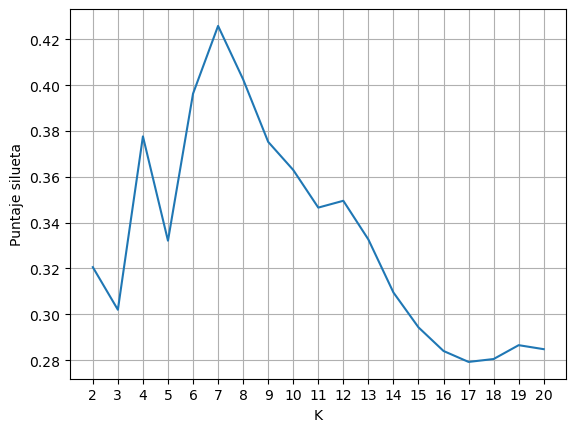

In [18]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Fijar inicialmente el mejor puntaje como -1 y el k correspondiente
# al mejor puntaje como 0
mejor_puntaje = -1
mejor_k = 0


# Crear listados con los valores de K y los puntajes (listado vacío)
K = list(range(2,21)) # 2:20
PUNTAJES = []

# Iterar sobre K y en cada iteración
# - Entrenar GMM con el valor de k (fit)
# - Clasificar datos con el modelo entrenado (predict)
# - Calcular puntaje y almacenar resultado
# - Actualizar "mejor_puntaje" y "mejor_k"
for k in K:
    gmm = GaussianMixture(n_components=k, random_state=42)
    y = gmm.fit_predict(X) # Entrenar + predecir
    puntaje = silhouette_score(X, y)
    PUNTAJES.append(puntaje)
    
    if puntaje > mejor_puntaje:
        mejor_puntaje = puntaje
        mejor_k = k

# Generar gráfica
plt.plot(K,PUNTAJES)
plt.xlabel('K')
plt.ylabel('Puntaje silueta')
plt.xticks(K)
plt.grid()

# E imprimir en pantalla el mejor puntaje y el número ideal de *clusters*
print(f'El mejor número de clusters (k) es: {mejor_k}')

## 7. Segmentación de los clientes

Muy bien, ya sabemos cuántos diferentes tipos de clientes tenemos: 7 en total.

Así que lo único que nos resta es ver algunas características de cada agrupación.

Comencemos entrenando el modelo y clasificando los datos usando precisamente k=7:

In [19]:
gmm = GaussianMixture(n_components=7, random_state=42)
y = gmm.fit_predict(X) # Entrenar + predecir
y

c:\Users\ASUS TUF\.conda\envs\ml-zoomcamp\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2,
       5, 2, 5, 2, 5, 6, 5, 2, 5, 2, 5, 2, 5, 2, 5, 6, 5, 2, 5, 2, 5, 6,
       5, 6, 0, 6, 6, 6, 0, 6, 6, 0, 0, 0, 0, 0, 6, 0, 0, 6, 0, 0, 0, 6,
       0, 0, 6, 6, 0, 0, 0, 0, 0, 6, 0, 0, 6, 0, 0, 0, 0, 0, 6, 0, 0, 6,
       0, 0, 0, 6, 0, 0, 6, 6, 0, 6, 0, 6, 6, 0, 0, 6, 0, 6, 0, 0, 0, 0,
       0, 6, 0, 6, 6, 6, 0, 0, 0, 0, 6, 0, 0, 4, 6, 4, 0, 4, 3, 4, 3, 4,
       6, 4, 3, 4, 3, 4, 3, 4, 3, 4, 6, 4, 3, 4, 0, 4, 3, 4, 3, 4, 3, 4,
       3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 1, 3, 4, 3, 4, 3, 4,
       3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1])

Y podemos por ejemplo caracterizar cada segmento por el promedio del cluster para cada variable/*feature*:

In [20]:
# Agregar columna de categorías al dataframe original
df['cat'] = y
df

,Edad,Ingresos,Puntaje,cat
ID,,,,
1,19,15,39,5
2,21,15,81,2
3,20,16,6,5
4,23,16,77,2
5,31,17,40,5
...,...,...,...,...
196,35,120,79,1
197,45,126,28,3
198,32,126,74,1


In [21]:
# Agrupar por categorías y sintetizar información mostrando la media y la desviación estándar de cada categoría
# y por cada variable
df.groupby('cat').aggregate(['mean', 'std'])

Edad               Ingresos               Puntaje           
          mean        std        mean        std       mean        std
cat                                                                   
0    53.326923  10.052258   55.750000   8.713017  49.076923   6.522498
1    32.875000   3.270539  111.250000  15.988835  76.500000   9.621405
2    24.578947   5.014599   24.473684   7.159829  81.421053   9.581903
3    41.454545  11.172206   89.090909  16.451375  16.181818   9.422230
4    32.645161   3.886287   80.161290   8.517029  83.580645   8.879843
5    45.217391  13.228607   26.304348   7.893811  20.913043  13.017167
6    24.911765   5.059450   53.764706  11.873216  50.676471   9.067827